<a href="https://colab.research.google.com/github/Krouw/data-science-2026/blob/main/Pertemuan5_Dimoriansa_Ramadhan_240401010367.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [18]:
# LOAD & INSPECT DATASET ──────────────────────────────────────────
df = sns.load_dataset('diamonds')

# INFORMASI DATA
print("Shape Dataset:")
print(df.shape)

print("\nTipe Data:")
print(df.dtypes)

print("\nStatistik Deskriptif:")
print(df.describe().round(2))

Shape Dataset:
(53940, 10)

Tipe Data:
carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object

Statistik Deskriptif:
          carat     depth     table     price         x         y         z
count  53940.00  53940.00  53940.00  53940.00  53940.00  53940.00  53940.00
mean       0.80     61.75     57.46   3932.80      5.73      5.73      3.54
std        0.47      1.43      2.23   3989.44      1.12      1.14      0.71
min        0.20     43.00     43.00    326.00      0.00      0.00      0.00
25%        0.40     61.00     56.00    950.00      4.71      4.72      2.91
50%        0.70     61.80     57.00   2401.00      5.70      5.71      3.53
75%        1.04     62.50     59.00   5324.25      6.54      6.54      4.04
max        5.01     79.00     95.00  18823.00     10.74     58.90     31.80


/tmp/ipykernel_8371/1622514981.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price_cut = df.groupby('cut')['price'].mean()


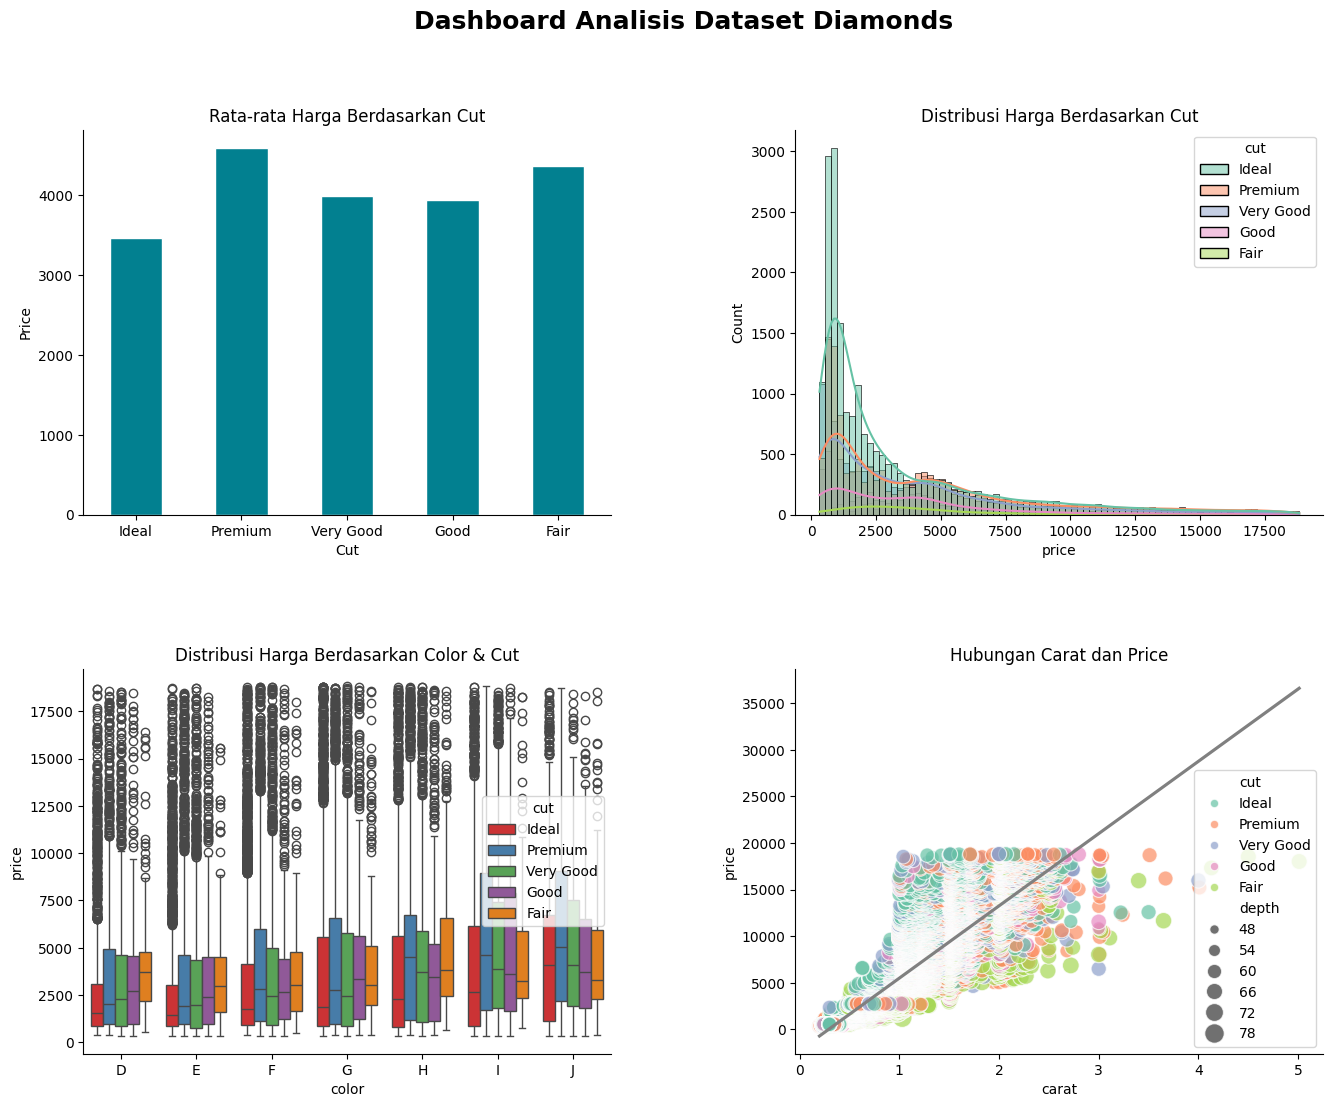

Dashboard tersimpan sebagai 'dashboard_diamonds.png'


In [21]:
# SETUP FIGURE LAYOUT ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))

fig.suptitle(
    'Dashboard Analisis Dataset Diamonds',
    fontsize=18,
    fontweight='bold',
    y=0.98
)

# Layout Grid 2x2
gs = gridspec.GridSpec(
    2, 2,
    figure=fig,
    hspace=0.4,
    wspace=0.35
)

# Membuat subplot
ax1 = fig.add_subplot(gs[0, 0])  # kiri atas
ax2 = fig.add_subplot(gs[0, 1])  # kanan atas
ax3 = fig.add_subplot(gs[1, 0])  # kiri bawah
ax4 = fig.add_subplot(gs[1, 1])  # kanan bawah

# GRAFIK 1: Bar Chart ─────────────────────────────────────────────
# Rata-rata harga berdasarkan cut

avg_price_cut = df.groupby('cut')['price'].mean()

avg_price_cut.plot(
    kind='bar',
    ax=ax1,
    color='#028090',
    edgecolor='white'
)

ax1.set_title('Rata-rata Harga Berdasarkan Cut')
ax1.set_xlabel('Cut')
ax1.set_ylabel('Price')
ax1.tick_params(axis='x', rotation=0)

# Menghilangkan garis atas & kanan
ax1.spines[['top', 'right']].set_visible(False)

# GRAFIK 2: Histogram + KDE ───────────────────────────────────────
# Distribusi harga berdasarkan cut

sns.histplot(
    data=df,
    x='price',
    hue='cut',
    kde=True,
    palette='Set2',
    ax=ax2
)

ax2.set_title('Distribusi Harga Berdasarkan Cut')
ax2.spines[['top', 'right']].set_visible(False)

# GRAFIK 3: Boxplot ───────────────────────────────────────────────
# Distribusi harga berdasarkan color & cut

sns.boxplot(
    data=df,
    x='color',
    y='price',
    hue='cut',
    palette='Set1',
    ax=ax3
)

ax3.set_title('Distribusi Harga Berdasarkan Color & Cut')
ax3.spines[['top', 'right']].set_visible(False)

# =========================================================
#  GRAFIK 4: Scatter Plot + REGRESSION LINE─────────────────────────
# Hubungan carat dan price

sns.scatterplot(
    data=df,
    x='carat',
    y='price',
    hue='cut',
    size='depth',
    sizes=(20, 200),
    palette='Set2',
    alpha=0.7,
    ax=ax4
)

# Garis regresi
sns.regplot(
    data=df,
    x='carat',
    y='price',
    scatter=False,
    color='gray',
    ax=ax4
)

ax4.set_title('Hubungan Carat dan Price')
ax4.spines[['top', 'right']].set_visible(False)

# EXPORT DASHBOARD───────────────────────────────────────────────────

plt.savefig(
    'dashboard_diamonds.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("Dashboard tersimpan sebagai 'dashboard_diamonds.png'")

1. Bar Chart — Rata-rata Harga Berdasarkan Cut

**What?**
Grafik menunjukkan bahwa kategori Premium memiliki rata-rata harga tertinggi, yaitu sekitar 4.584, diikuti oleh Fair sekitar 4.358. Sementara itu, kategori Ideal memiliki rata-rata harga paling rendah, sekitar 3.458. Perbedaan harga antar kategori cut terlihat cukup signifikan, terutama antara Ideal dan Premium.

**So what?**
Hal ini menunjukkan bahwa kualitas potongan (cut) memengaruhi nilai jual berlian. Namun menariknya, kategori Ideal tidak memiliki harga tertinggi meskipun dianggap kualitas potongan terbaik. Ini menandakan bahwa harga berlian tidak hanya dipengaruhi oleh cut, tetapi juga faktor lain seperti carat, clarity, dan color.

**Now what?**
Analisis berikutnya dapat mengeksplorasi hubungan antara cut dan faktor lain seperti ukuran carat atau tingkat kejernihan. Selain itu, dapat dilakukan analisis apakah berlian dengan cut Premium cenderung memiliki carat lebih besar dibanding kategori lainnya.

2. **Histogram** — Distribusi Harga Berdasarkan Cut

**What?**
Distribusi harga berlian terlihat miring ke kanan (right-skewed), di mana sebagian besar berlian berada pada rentang harga 500–3.000. Kategori Ideal mendominasi jumlah data dengan frekuensi tertinggi mencapai lebih dari 3.000 data pada harga rendah. Sementara harga sangat tinggi di atas 15.000 jumlahnya relatif sedikit pada semua kategori cut.

**So what?**
Distribusi ini menunjukkan bahwa pasar berlian lebih banyak terdiri dari produk dengan harga menengah ke bawah. Data yang tidak simetris juga mengindikasikan adanya banyak outlier pada harga tinggi. Kondisi ini penting karena rata-rata harga dapat menjadi kurang representatif jika distribusi terlalu condong.

**Now what?**
Langkah selanjutnya adalah menghitung median dan kuartil harga untuk mendapatkan gambaran yang lebih stabil dibanding mean. Selain itu, analisis log-transform pada variabel harga dapat membantu membuat distribusi lebih normal sehingga lebih mudah dianalisis secara statistik.

3. **Boxplot** — Distribusi Harga Berdasarkan Color & Cut

**What?**
Boxplot memperlihatkan bahwa semakin mendekati warna J, median harga cenderung meningkat dibanding warna D. Banyak titik outlier ditemukan pada hampir semua kategori, dengan beberapa harga mencapai lebih dari 18.000. Variasi harga juga tampak lebih besar pada kategori warna seperti H, I, dan J.

**So what?**
Hal ini menunjukkan bahwa warna berlian tidak selalu menentukan harga secara sederhana. Walaupun warna D biasanya dianggap lebih baik, data menunjukkan bahwa berlian warna rendah tetap dapat memiliki harga tinggi, kemungkinan karena ukuran carat yang lebih besar. Banyaknya outlier juga menandakan variasi pasar berlian sangat tinggi.

**Now what?**
Analisis lanjutan dapat dilakukan dengan memisahkan data berdasarkan rentang carat agar pengaruh warna terhadap harga lebih jelas terlihat. Selain itu, dapat dibuat heatmap korelasi antar fitur numerik untuk mengetahui faktor mana yang paling dominan memengaruhi harga.

4. Scatter Plot — Hubungan Carat dan Price

What?
Scatter plot menunjukkan hubungan positif yang kuat antara carat dan price. Semakin besar ukuran carat, harga berlian cenderung meningkat, bahkan hingga lebih dari 35.000 pada carat di atas 4. Sebagian besar data terkonsentrasi pada ukuran 0,5–2 carat dengan harga di bawah 15.000.

So what?
Hubungan ini menegaskan bahwa ukuran berlian merupakan faktor utama dalam menentukan harga. Garis regresi yang terus naik menunjukkan korelasi linear positif yang cukup kuat antara kedua variabel. Informasi ini penting untuk prediksi harga maupun penentuan strategi penjualan berlian.

Now what?
Langkah berikutnya adalah
menghitung nilai korelasi Pearson antara carat dan price untuk mengukur kekuatan hubungan secara numerik. Selain itu,
model regresi dapat dibangun untuk memprediksi harga berlian berdasarkan carat dan variabel lainnya seperti cut, color, dan clarity.